In [6]:
%run SSRtransforms_updated.py
import os
import matplotlib.pyplot as plt

In [8]:
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML" 
# workspace = "/workspace/alvin/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [2]:
def read_mstar_clutter(filepath):
    with open(filepath, 'rb') as f:
        raw = f.read()
    
    header = raw[:2000].decode('ascii', errors='ignore')
    
    rows = int([l for l in header.splitlines() if 'NumberOfRows' in l][0].split('=')[1])
    cols = int([l for l in header.splitlines() if 'NumberOfColumns' in l][0].split('=')[1])
    header_length = int([l for l in header.splitlines() if 'PhoenixHeaderLength' in l][0].split('=')[1])
    
    # data starts after full phoenix header
    data = np.frombuffer(raw[header_length:], dtype='>f4')
    
    # clutter files are magnitude only (unlike target chips which have mag+phase)
    magnitude = data[:rows*cols].reshape(rows, cols)
    return magnitude

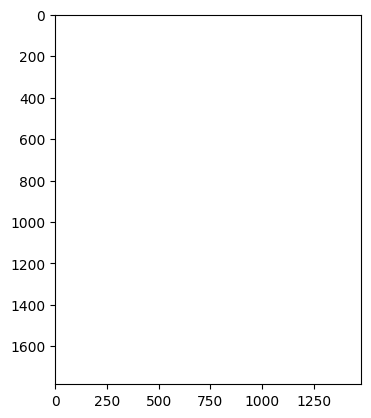

In [10]:
plt.imshow(
    read_mstar_clutter(
        os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG/HB06277")
    ),
    cmap = "gray"
)

In [11]:
log_mapper = LogMapping(c = 1000.0)

In [22]:
test_clutter = read_mstar_clutter(
        os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG/HB06158")
)

In [29]:
test_clutter_clipped = np.clip(test_clutter, 0, np.percentile(test_clutter, 95))

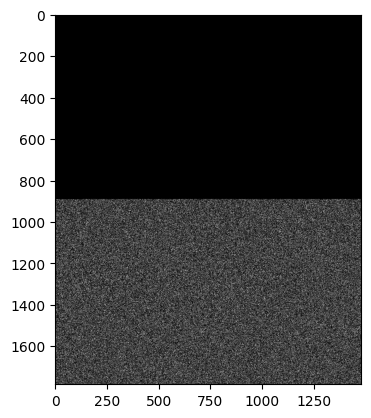

In [30]:
plt.imshow(log_mapper(test_clutter_clipped), cmap = "gray")

In [31]:
np.unique(log_mapper(test_clutter_clipped), return_counts = True)

(array([0.0000000e+00, 1.7254814e-08, 3.4509625e-08, ..., 9.9999988e-01,
        1.0000000e+00, 1.0000001e+00], shape=(428855,), dtype=float32),
 array([  3563,  18206,  32068, ...,      1,      1, 131838],
       shape=(428855,)))